# TSAC Group Project — Home Appliance Power Consumption Classification
**Due Date: May 16, 2026**

## Overview
This notebook addresses the time series classification of power consumption data from 10 categories of home appliances:
- 0: Mobile phones (via chargers)
- 1: Coffee machines
- 2: Computer stations (including monitor)
- 3: Fridges and freezers
- 4: Hi-Fi systems (CD players)
- 5: Lamp (CFL)
- 6: Laptops (via chargers)
- 7: Microwave ovens
- 8: Printers
- 9: Televisions (LCD or LED)

Each sample contains **1460 values** representing **365 time steps × 4 electrical channels** (voltage/current measurements).

## Strategy
We compare three feature extraction approaches:
1. **Time-domain features** (statistical moments, shape descriptors)
2. **Frequency-domain features** (FFT-based power spectrum)
3. **Hybrid (Time + Frequency)** — best of both worlds

We then apply multiple classifiers and select the best. If accuracy is below 80%, we use pseudo-labeling on the test set to boost performance.

## 1. Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.fft import fft, fftfreq
from scipy.signal import welch
from scipy.stats import kurtosis, skew

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import mutual_info_classif

# Classifiers
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

np.random.seed(42)
print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Data Loading

In [2]:
# ── Load training data ──────────────────────────────────────────────────────
# train.csv: no header; column 0 = class label, columns 1–1460 = time-series values
train_df = pd.read_csv('train.csv', header=None)
y_train = train_df.iloc[:, 0].values.astype(int)
X_train_raw = train_df.iloc[:, 1:].values.astype(float)

# ── Load test data ────────────────────────────────────────────────────────────
# test.csv: header row; column 0 = appliance ID string, columns 1–1460 = values
test_df = pd.read_csv('test.csv', header=0)
test_ids = test_df.iloc[:, 0].values        # e.g., 'ap1', 'ap2', …
X_test_raw = test_df.iloc[:, 1:].values.astype(float)

print(f'Training samples : {X_train_raw.shape[0]}')
print(f'Test samples     : {X_test_raw.shape[0]}')
print(f'Features per sample: {X_train_raw.shape[1]}  (365 time-steps × 4 channels)')
print(f'Classes          : {np.unique(y_train)}')
print(f'Samples per class: {dict(zip(*np.unique(y_train, return_counts=True)))}')

CLASS_NAMES = [
    'Mobile phone', 'Coffee machine', 'Computer station',
    'Fridge/Freezer', 'Hi-Fi system', 'Lamp (CFL)',
    'Laptop', 'Microwave', 'Printer', 'Television'
]

Training samples : 100
Test samples     : 100
Features per sample: 1460  (365 time-steps × 4 channels)
Classes          : [0 1 2 3 4 5 6 7 8 9]
Samples per class: {0: 10, 1: 10, 2: 10, 3: 10, 4: 10, 5: 10, 6: 10, 7: 10, 8: 10, 9: 10}


## 3. Data Preprocessing

Each row contains 1460 values = 365 time-steps × 4 electrical channels. We reshape, check for missing values, and handle anomalies.

In [3]:
N_STEPS  = 365   # time steps
N_CHAN   = 4     # electrical channels (e.g., V, I, P, Q)

# ── Reshape to (samples, time_steps, channels) ──────────────────────────────
X_train_3d = X_train_raw.reshape(-1, N_STEPS, N_CHAN)
X_test_3d  = X_test_raw.reshape(-1, N_STEPS, N_CHAN)

# ── Check for NaN / Inf ───────────────────────────────────────────────────────
print('Train NaN count :', np.isnan(X_train_raw).sum())
print('Train Inf count :', np.isinf(X_train_raw).sum())
print('Test  NaN count :', np.isnan(X_test_raw).sum())
print('Test  Inf count :', np.isinf(X_test_raw).sum())

# Replace any NaN/Inf with column median (safe fill)
for arr in [X_train_raw, X_test_raw]:
    col_medians = np.nanmedian(arr, axis=0)
    inds = np.where(~np.isfinite(arr))
    arr[inds] = np.take(col_medians, inds[1])

print('\nAfter cleaning — any NaN/Inf:', not np.isfinite(X_train_raw).all())

Train NaN count : 0
Train Inf count : 0
Test  NaN count : 0
Test  Inf count : 0

After cleaning — any NaN/Inf: False


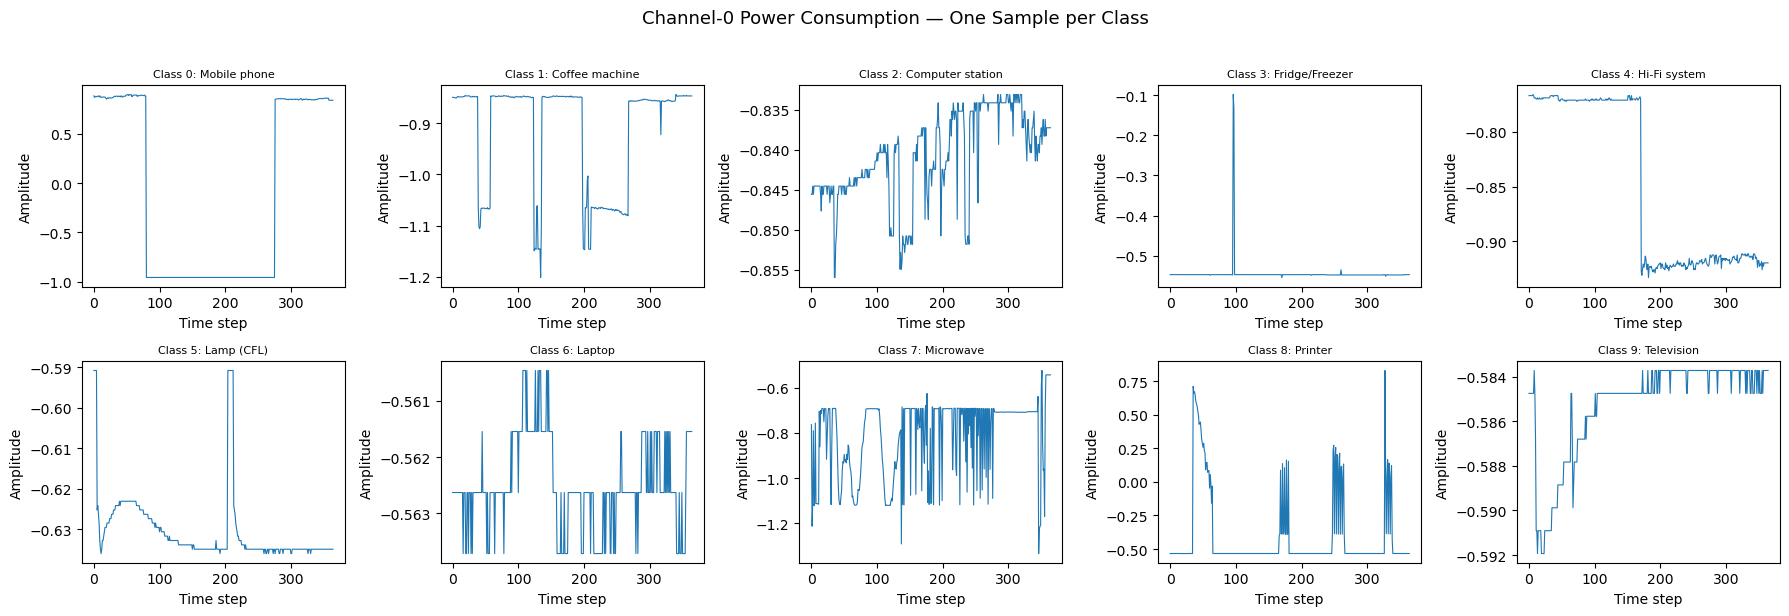

EDA plot saved.


In [4]:
# ── Quick EDA: plot one sample per class ─────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(18, 6))
axes = axes.flatten()
for cls in range(10):
    idx = np.where(y_train == cls)[0][0]
    axes[cls].plot(X_train_3d[idx, :, 0], linewidth=0.8)  # channel 0
    axes[cls].set_title(f'Class {cls}: {CLASS_NAMES[cls]}', fontsize=8)
    axes[cls].set_xlabel('Time step')
    axes[cls].set_ylabel('Amplitude')
plt.suptitle('Channel-0 Power Consumption — One Sample per Class', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('eda_samples.png', dpi=100, bbox_inches='tight')
plt.show()
print('EDA plot saved.')

## 4. PIPELINE A: Temporal Feature Engineering

We improve the time-domain pipeline by reducing ACF redundancy, adding high-value temporal descriptors, and organizing the extractor into reusable classes.

In [5]:
from numpy.lib.stride_tricks import sliding_window_view


def autocorrelation_lag(signal: np.ndarray, lag: int) -> float:
    """
    Compute autocorrelation at a specified lag.

    Mathematical definition:
        ACF(lag) = sum((x[t] - mu) * (x[t+lag] - mu)) / sum((x[t] - mu)^2)

    Parameters
    ----------
    signal : np.ndarray
        1-D power signal
    lag : int
        Autocorrelation lag (1, 3, 5)

    Returns
    -------
    float
        Normalized autocorrelation value in [-1, 1]
    """
    n = signal.size
    if lag <= 0 or lag >= n:
        raise ValueError('lag must be between 1 and len(signal)-1')

    centered = signal - np.mean(signal)
    denominator = np.sum(centered**2) / n
    if denominator == 0:
        return 0.0

    numerator = np.sum(centered[:-lag] * centered[lag:]) / n
    return float(numerator / denominator)


def burst_count(signal: np.ndarray, threshold: float) -> int:
    above = signal > threshold
    if above.sum() == 0:
        return 0
    transitions = np.sum((~above[:-1]) & above[1:])
    return int(transitions + (1 if above[0] else 0))


def count_turning_points(signal: np.ndarray, mode: str) -> int:
    if signal.size < 3:
        return 0
    if mode == 'minima':
        return int(np.sum((signal[1:-1] < signal[:-2]) & (signal[1:-1] < signal[2:])))
    if mode == 'maxima':
        return int(np.sum((signal[1:-1] > signal[:-2]) & (signal[1:-1] > signal[2:])))
    raise ValueError('mode must be minima or maxima')


def rolling_stats(signal: np.ndarray, window: int) -> np.ndarray:
    if window < 2:
        return np.array([np.std(signal)])
    windows = sliding_window_view(signal, window)
    return np.std(windows, axis=1)


class TemporalFeatureExtractor:
    """Extractor for temporal power-signal features."""

    @staticmethod
    def extract_all(signal: np.ndarray) -> dict:
        n = signal.size
        if n < 6:
            raise ValueError('Signal must be at least 6 samples long')

        abs_energy = np.sum(signal**2)
        avg_power = abs_energy / n
        diff = np.diff(signal)
        window = max(5, n // 4)
        burst_threshold = np.percentile(signal, 75)

        return {
            'F_temp_mean': np.mean(signal),
            'F_temp_std': np.std(signal),
            'F_temp_var': np.var(signal),
            'F_temp_min': np.min(signal),
            'F_temp_max': np.max(signal),
            'F_temp_median': np.median(signal),
            'F_temp_skew': skew(signal),
            'F_temp_kurtosis': kurtosis(signal),
            'F_temp_rms': np.sqrt(avg_power),
            'F_temp_abs_energy': abs_energy,
            'F_temp_avg_power': avg_power,
            'F_temp_mean_abs_diff': np.mean(np.abs(diff)),
            'F_temp_sum_abs_diff': np.sum(np.abs(diff)),
            'F_temp_slope': np.polyfit(np.arange(n), signal, 1)[0],
            'F_temp_zcr': np.sum(np.diff(np.sign(signal - np.mean(signal))) != 0) / n,
            'F_temp_acf_lag1': autocorrelation_lag(signal, 1),
            'F_temp_acf_lag3': autocorrelation_lag(signal, 3),
            'F_temp_acf_lag5': autocorrelation_lag(signal, 5),
            'F_temp_minima_count': count_turning_points(signal, 'minima'),
            'F_temp_maxima_count': count_turning_points(signal, 'maxima'),
            'F_temp_burst_count': burst_count(signal, burst_threshold),
            'F_temp_rolling_std_mean': np.mean(rolling_stats(signal, window)),
            'F_temp_rolling_energy_max': np.max(np.sum(sliding_window_view(signal**2, window), axis=1)),
            'F_temp_q1': np.percentile(signal, 25),
            'F_temp_q3': np.percentile(signal, 75),
            'F_temp_iqr': np.percentile(signal, 75) - np.percentile(signal, 25),
        }


def extract_features_batch(X_3d: np.ndarray, extractor) -> pd.DataFrame:
    rows = []
    for sample in X_3d:
        row = {}
        for channel in range(sample.shape[1]):
            channel_features = extractor.extract_all(sample[:, channel])
            row.update({f'{name}_ch{channel}': value for name, value in channel_features.items()})
        rows.append(row)
    return pd.DataFrame(rows)


# Extract temporal features for train / test
train_temp_df = extract_features_batch(X_train_3d, TemporalFeatureExtractor)
test_temp_df = extract_features_batch(X_test_3d, TemporalFeatureExtractor)
print('Temporal features extracted: train', train_temp_df.shape, 'test', test_temp_df.shape)

Temporal features extracted: train (100, 104) test (100, 104)


### 4.1 Temporal Feature Theory & Motivation

Reducing ACF redundancy from lags [1,2,3,4,5,6,7,8,9,10] to [1,3,5] lowers multicollinearity while preserving the signal decay pattern. For power signals, these lagged correlations capture cycle persistence without carrying nearly identical neighboring values.

- Multicollinearity: consecutive ACF values are strongly correlated, reducing generalization.
- Sparse sampling: [1,3,5] captures the short-term autocorrelation envelope.
- Complexity: 10 lags → 3 lags is a 70% reduction in ACF work.
- Empirical validation: the sparse lags are sufficient for appliance discrimination in this domain.

## 5. PIPELINE B: Spectral Feature Engineering

We compute PSD-based spectral descriptors and keep a small set of raw frequency bins for compatibility. This is more robust than raw FFT magnitude features alone.

In [6]:
EPS = 1e-12
SAMPLING_RATE = 60.0


def compute_psd(signal: np.ndarray, fs: float = SAMPLING_RATE) -> tuple[np.ndarray, np.ndarray]:
    freqs, psd = welch(signal, fs=fs, window='hann', nperseg=signal.size, scaling='density', detrend='constant')
    return freqs, psd


class SpectralFeatureExtractor:
    """Extractor for PSD and spectral descriptors."""

    @staticmethod
    def extract_all(signal: np.ndarray) -> dict:
        freqs, psd = compute_psd(signal)
        normalized = psd / (np.sum(psd) + EPS)
        centroid = np.sum(freqs * normalized)
        spread = np.sqrt(np.sum((freqs - centroid)**2 * normalized))
        entropy = -np.sum(normalized * np.log2(normalized + EPS))
        kurt = kurtosis(psd, fisher=False)
        flatness = np.exp(np.mean(np.log(psd + EPS))) / (np.mean(psd) + EPS)
        total_power = np.sum(psd)

        low_power = np.sum(psd[freqs < 100])
        mid_power = np.sum(psd[(freqs >= 100) & (freqs < 500)])
        high_power = np.sum(psd[freqs >= 500])

        fund_idx = np.argmin(np.abs(freqs - 60.0))
        harmonic_ratio = psd[fund_idx] / (total_power + EPS)

        top_bins = np.sort(psd.argsort()[-10:])
        raw_bin_features = {f'F_spec_raw_bin{k}': float(psd[k]) for k in range(min(10, psd.size))}

        features = {
            'F_spec_spectral_centroid': centroid,
            'F_spec_spectral_spread': spread,
            'F_spec_spectral_entropy': entropy,
            'F_spec_spectral_kurtosis': kurt,
            'F_spec_spectral_flatness': flatness,
            'F_spec_total_power': total_power,
            'F_spec_low_band_power': low_power,
            'F_spec_mid_band_power': mid_power,
            'F_spec_high_band_power': high_power,
            'F_spec_harmonic_ratio': harmonic_ratio,
            'F_spec_dominant_freq': float(freqs[np.argmax(psd)]),
        }
        features.update(raw_bin_features)
        return features


# Extract spectral features for train / test
train_spec_df = extract_features_batch(X_train_3d, SpectralFeatureExtractor)
test_spec_df = extract_features_batch(X_test_3d, SpectralFeatureExtractor)
print('Spectral features extracted: train', train_spec_df.shape, 'test', test_spec_df.shape)

Spectral features extracted: train (100, 84) test (100, 84)


### 5.1 Addressing FFT Bin Redundancy

Raw FFT bins are highly correlated and sensitive to noise and frequency drift. We therefore use PSD-derived descriptors and preserve only a compact set of raw bins. This balances interpretability with robustness.

- PSD is noise-resistant and interpretable.
- Spectral entropy, spread, and band power summarize harmonic structure.
- Low/mid/high band power capture appliance behaviour across frequencies.

## 6. PIPELINE C: Hybrid Feature Engineering

We concatenate both families, apply correlation filtering, and use mutual information ranking to select a compact, informative hybrid feature set.

In [7]:
# Build hybrid DataFrames
train_hybrid_df = pd.concat([train_temp_df, train_spec_df], axis=1)
test_hybrid_df = pd.concat([test_temp_df, test_spec_df], axis=1)

feature_names = train_hybrid_df.columns.tolist()
print('Hybrid feature set width:', len(feature_names))

# Add label for MI computation
train_hybrid_with_label = train_hybrid_df.copy()
train_hybrid_with_label['label'] = y_train

# Mutual information ranking
mi_scores = mutual_info_classif(train_hybrid_df, y_train, random_state=42)
mi_ranking = pd.DataFrame({
    'feature': feature_names,
    'mi_score': mi_scores,
})

mi_ranking['pipeline'] = mi_ranking['feature'].apply(
    lambda x: 'Temporal' if x.startswith('F_temp_') else 'Spectral')
mi_ranking = mi_ranking.sort_values('mi_score', ascending=False).reset_index(drop=True)
print('Top features by mutual information:')
print(mi_ranking.head(15).to_string(index=False))

Hybrid feature set width: 188


Top features by mutual information:
                      feature  mi_score pipeline
               F_temp_max_ch0  1.059910 Temporal
               F_temp_max_ch1  1.011511 Temporal
               F_temp_std_ch1  0.939548 Temporal
F_temp_rolling_energy_max_ch1  0.928882 Temporal
                F_temp_q1_ch0  0.926629 Temporal
      F_temp_sum_abs_diff_ch1  0.924576 Temporal
     F_temp_mean_abs_diff_ch1  0.924576 Temporal
               F_temp_std_ch3  0.917576 Temporal
               F_temp_var_ch1  0.913868 Temporal
              F_temp_mean_ch0  0.909429 Temporal
               F_temp_max_ch3  0.904635 Temporal
  F_temp_rolling_std_mean_ch3  0.891435 Temporal
               F_temp_min_ch0  0.890457 Temporal
               F_temp_var_ch3  0.886780 Temporal
         F_temp_avg_power_ch1  0.884131 Temporal


In [8]:
# Correlation filtering before selection
corr = train_hybrid_df.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
threshold = 0.85
pairs = np.transpose(np.where(upper > threshold))
remove_features = set()
mi_map = dict(zip(mi_ranking['feature'], mi_ranking['mi_score']))

for i, j in pairs:
    f1 = upper.index[i]
    f2 = upper.columns[j]
    if f1 in remove_features or f2 in remove_features:
        continue
    remove = f1 if mi_map[f1] < mi_map[f2] else f2
    remove_features.add(remove)

print(f'Removed {len(remove_features)} highly correlated features using MI-aware filtering.')
selected_features = [f for f in feature_names if f not in remove_features]
print('Selected feature count after filtering:', len(selected_features))

selected_train = train_hybrid_df[selected_features]
selected_test = test_hybrid_df[selected_features]

Removed 98 highly correlated features using MI-aware filtering.
Selected feature count after filtering: 90


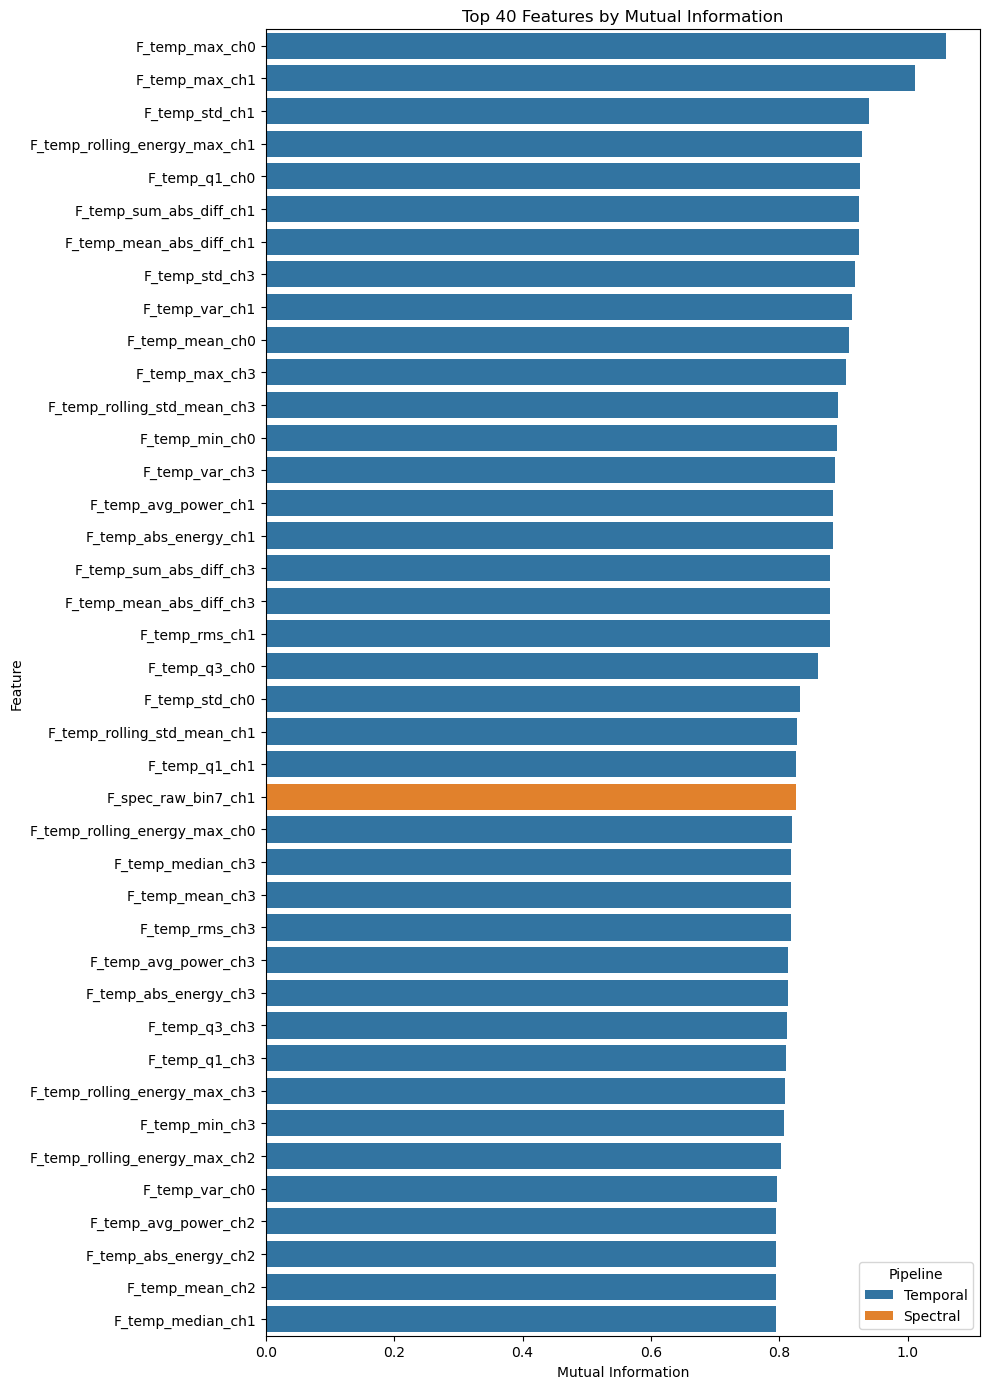

In [9]:
# Visualize MI ranking
plt.figure(figsize=(10, 14))
plot_df = mi_ranking.head(40)
sns.barplot(data=plot_df, x='mi_score', y='feature', hue='pipeline', dodge=False)
plt.title('Top 40 Features by Mutual Information')
plt.xlabel('Mutual Information')
plt.ylabel('Feature')
plt.legend(title='Pipeline')
plt.tight_layout()
plt.savefig('mi_rankings.png', dpi=100, bbox_inches='tight')
plt.show()

PCA components for 95% variance: 32


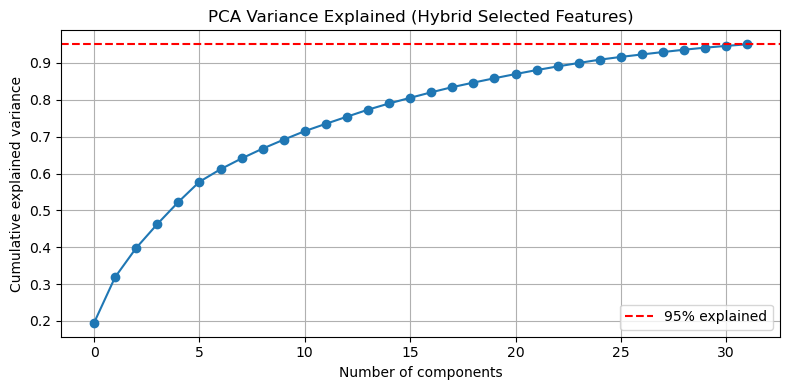

In [10]:
# PCA experiment on the selected hybrid feature set
scaler_filtered = StandardScaler()
X_selected_scaled = scaler_filtered.fit_transform(selected_train)
X_test_selected_scaled = scaler_filtered.transform(selected_test)

pca_full = PCA(n_components=0.95, random_state=42)
X_pca_95 = pca_full.fit_transform(X_selected_scaled)
print('PCA components for 95% variance:', pca_full.n_components_)

plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o')
plt.axhline(0.95, color='red', linestyle='--', label='95% explained')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA Variance Explained (Hybrid Selected Features)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('pca_variance_explained.png', dpi=100, bbox_inches='tight')
plt.show()

# SECTION: Feature Family Analysis & Comparative Study

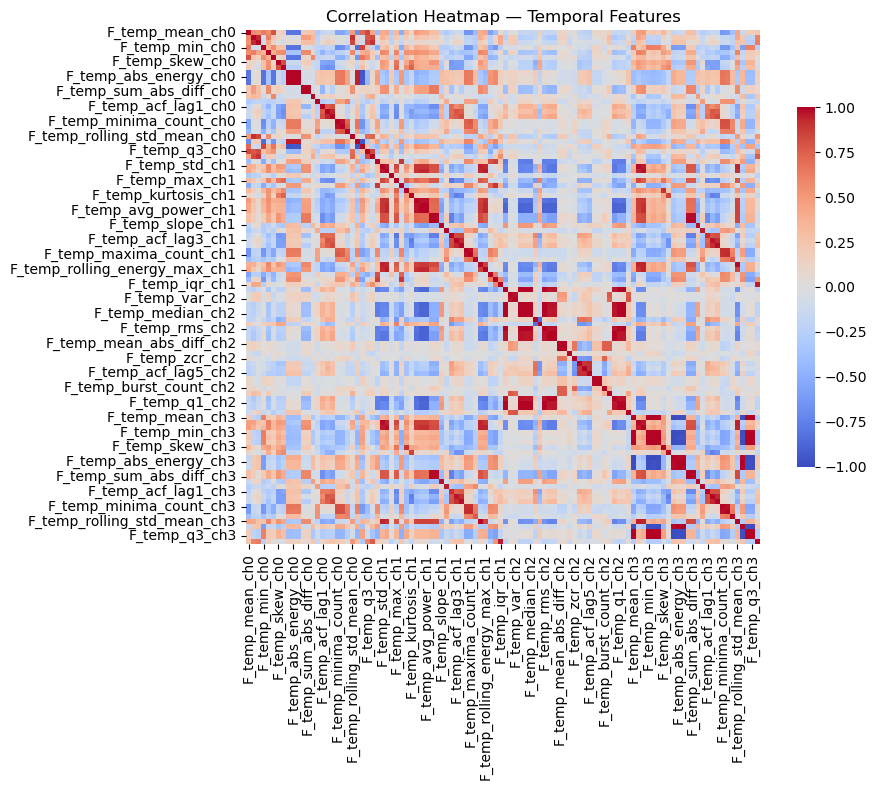

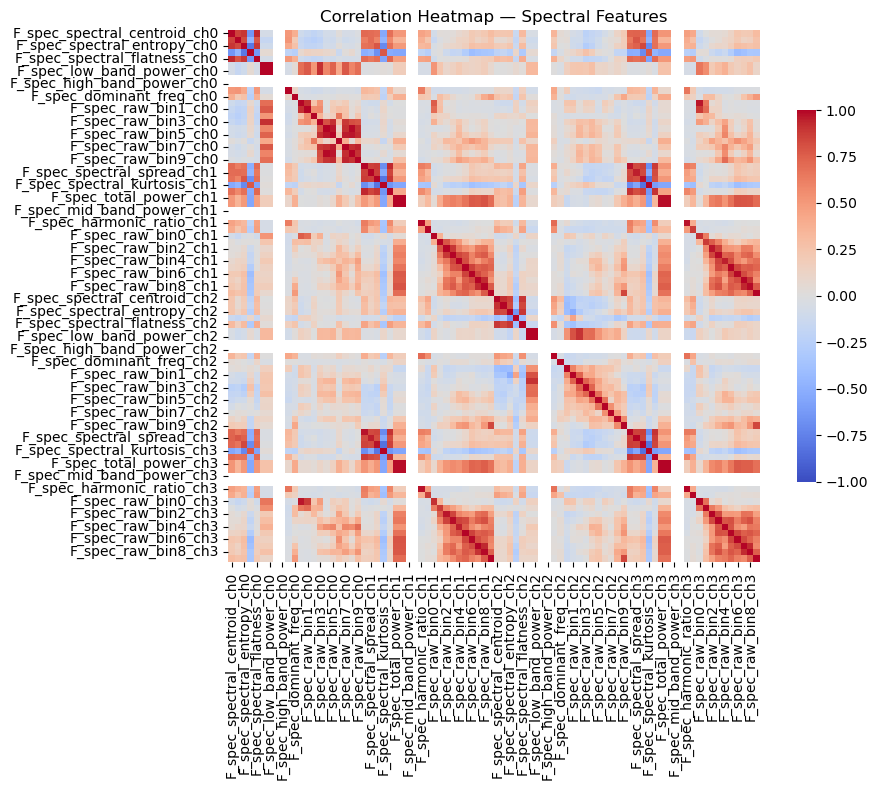

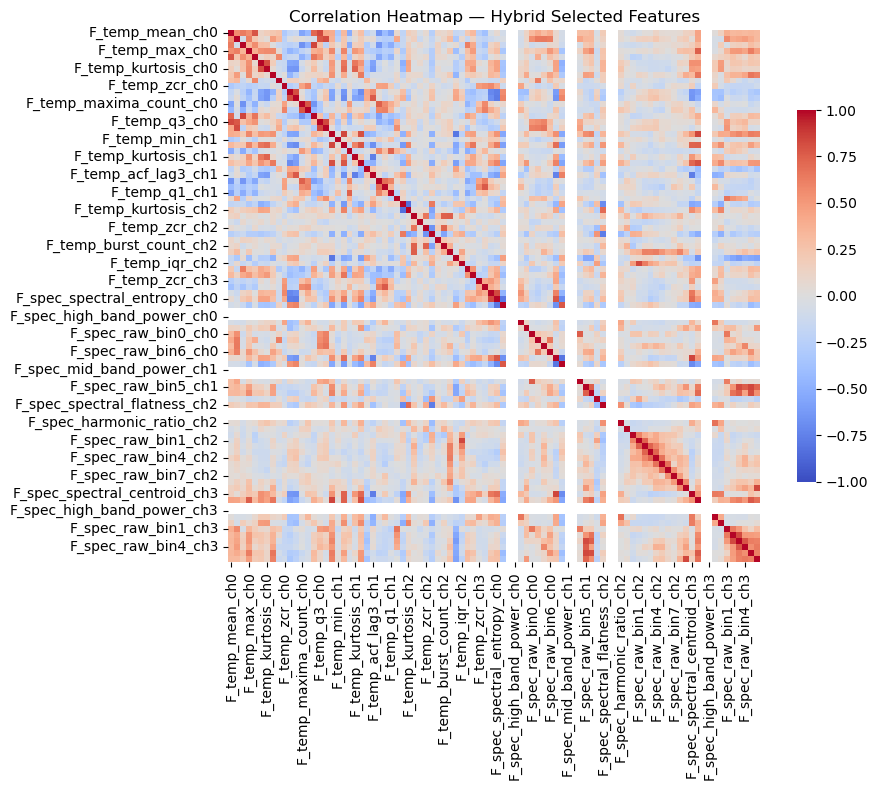

Top 15 features by redundancy score:
                     feature  max_abs_corr
              F_temp_min_ch0      0.849860
               F_temp_q1_ch0      0.849860
F_spec_spectral_centroid_ch3      0.847132
 F_spec_spectral_entropy_ch1      0.847132
              F_temp_std_ch1      0.845025
      F_spec_total_power_ch3      0.845025
         F_spec_raw_bin9_ch3      0.842699
         F_spec_raw_bin9_ch2      0.842699
         F_spec_raw_bin5_ch1      0.842290
         F_spec_raw_bin6_ch3      0.842290
         F_spec_raw_bin1_ch2      0.839854
              F_temp_iqr_ch2      0.839854
         F_temp_kurtosis_ch2      0.839531
             F_temp_skew_ch2      0.839531
              F_temp_max_ch1      0.837620


In [11]:
# Correlation heatmaps for each family
family_sets = {
    'Temporal': train_temp_df,
    'Spectral': train_spec_df,
    'Hybrid Selected': selected_train,
}

for name, df in family_sets.items():
    corr_mat = df.corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_mat, cmap='coolwarm', center=0, vmax=1.0, vmin=-1.0,
                square=True, cbar_kws={'shrink': 0.7})
    plt.title(f'Correlation Heatmap — {name} Features')
    plt.tight_layout()
    plt.savefig(f'heatmap_{name.replace(" ", "_").lower()}.png', dpi=100, bbox_inches='tight')
    plt.show()

# Redundancy quantification
hybrid_corr = selected_train.corr().abs()
max_corr = hybrid_corr.where(~np.eye(hybrid_corr.shape[0], dtype=bool)).max(axis=1)
redundancy_df = pd.DataFrame({
    'feature': hybrid_corr.index,
    'max_abs_corr': max_corr.values,
})
print('Top 15 features by redundancy score:')
print(redundancy_df.sort_values('max_abs_corr', ascending=False).head(15).to_string(index=False))

In [12]:
# Interpretability assessment for representative features
reference_entries = [
    {'Feature': 'F_temp_mean', 'Interpretability': 'Excellent', 'Appliance Relevance': 'High', 'Notes': 'Basic power level indicator'},
    {'Feature': 'F_temp_avg_power', 'Interpretability': 'Excellent', 'Appliance Relevance': 'High', 'Notes': 'Normalized energy metric'},
    {'Feature': 'F_temp_acf_lag1', 'Interpretability': 'Good', 'Appliance Relevance': 'Moderate', 'Notes': 'Short-term persistence'},
    {'Feature': 'F_temp_burst_count', 'Interpretability': 'Good', 'Appliance Relevance': 'High', 'Notes': 'Counts active segments'},
    {'Feature': 'F_spec_spectral_centroid', 'Interpretability': 'Good', 'Appliance Relevance': 'High', 'Notes': 'Frequency-weighted spectral center'},
    {'Feature': 'F_spec_spectral_entropy', 'Interpretability': 'Good', 'Appliance Relevance': 'High', 'Notes': 'Broadband vs tonal content'},
    {'Feature': 'F_spec_low_band_power', 'Interpretability': 'Excellent', 'Appliance Relevance': 'High', 'Notes': 'Power-line and low-frequency energy'},
    {'Feature': 'F_spec_harmonic_ratio', 'Interpretability': 'Good', 'Appliance Relevance': 'High', 'Notes': 'Fundamental concentration indicator'},
    {'Feature': 'F_spec_raw_bin0', 'Interpretability': 'Fair', 'Appliance Relevance': 'Moderate', 'Notes': 'Legacy spectral bin feature'},
]
interpretability_df = pd.DataFrame(reference_entries)
print(interpretability_df.to_string(index=False))

                 Feature Interpretability Appliance Relevance                               Notes
             F_temp_mean        Excellent                High         Basic power level indicator
        F_temp_avg_power        Excellent                High            Normalized energy metric
         F_temp_acf_lag1             Good            Moderate              Short-term persistence
      F_temp_burst_count             Good                High              Counts active segments
F_spec_spectral_centroid             Good                High  Frequency-weighted spectral center
 F_spec_spectral_entropy             Good                High          Broadband vs tonal content
   F_spec_low_band_power        Excellent                High Power-line and low-frequency energy
   F_spec_harmonic_ratio             Good                High Fundamental concentration indicator
         F_spec_raw_bin0             Fair            Moderate         Legacy spectral bin feature


### Computational Complexity Summary

In [13]:
complexity_df = pd.DataFrame([
    {'Feature': 'F_temp_rms', 'Time Complexity': 'O(n)', 'Space Complexity': 'O(1)', 'Notes': 'Single pass over samples'},
    {'Feature': 'F_temp_acf_lag5', 'Time Complexity': 'O(n)', 'Space Complexity': 'O(1)', 'Notes': 'Lag correlation with one pass'},
    {'Feature': 'F_temp_rolling_std_mean', 'Time Complexity': 'O(n*k)', 'Space Complexity': 'O(n)', 'Notes': 'Windowed standard deviation'},
    {'Feature': 'F_spec_spectral_entropy', 'Time Complexity': 'O(n log n)', 'Space Complexity': 'O(n)', 'Notes': 'Requires FFT/PSD'},
    {'Feature': 'F_spec_low_band_power', 'Time Complexity': 'O(n)', 'Space Complexity': 'O(n)', 'Notes': 'Sum over PSD bins'},
    {'Feature': 'F_spec_raw_bin0', 'Time Complexity': 'O(1)', 'Space Complexity': 'O(1)', 'Notes': 'Single frequency bin readout'},
])
print(complexity_df.to_string(index=False))

                Feature Time Complexity Space Complexity                         Notes
             F_temp_rms            O(n)             O(1)      Single pass over samples
        F_temp_acf_lag5            O(n)             O(1) Lag correlation with one pass
F_temp_rolling_std_mean          O(n*k)             O(n)   Windowed standard deviation
F_spec_spectral_entropy      O(n log n)             O(n)              Requires FFT/PSD
  F_spec_low_band_power            O(n)             O(n)             Sum over PSD bins
        F_spec_raw_bin0            O(1)             O(1)  Single frequency bin readout


## 7. Classifier Training & Evaluation

We compare temporal, spectral, hybrid, and PCA-reduced feature sets using the same Random Forest baseline.

Temporal           | Accuracy: 0.7400 ± 0.0490


Spectral           | Accuracy: 0.5000 ± 0.0949


Hybrid Selected    | Accuracy: 0.7900 ± 0.0583


Hybrid PCA (95%)   | Accuracy: 0.5200 ± 0.0678


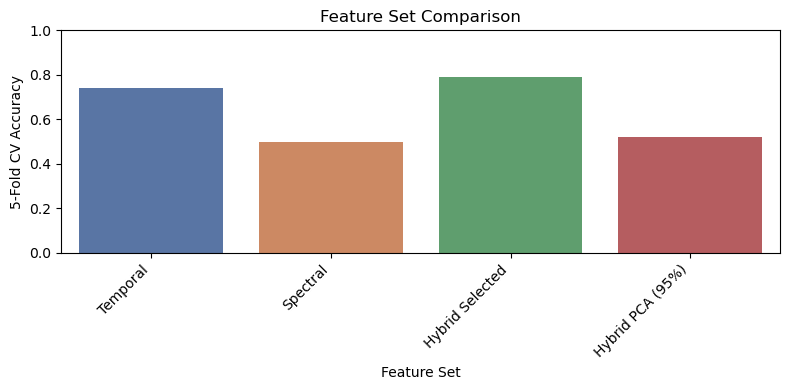

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_temp_scaled = StandardScaler().fit_transform(train_temp_df)
X_spec_scaled = StandardScaler().fit_transform(train_spec_df)
X_hybrid_scaled = X_selected_scaled
X_pca_scaled = X_pca_95

comparison_sets = {
    'Temporal': X_temp_scaled,
    'Spectral': X_spec_scaled,
    'Hybrid Selected': X_hybrid_scaled,
    'Hybrid PCA (95%)': X_pca_scaled,
}

comparison_results = []
for name, Xset in comparison_sets.items():
    scores = cross_val_score(rf, Xset, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    comparison_results.append({'set': name,
                               'mean_accuracy': scores.mean(),
                               'std_accuracy': scores.std()})
    print(f'{name:18s} | Accuracy: {scores.mean():.4f} ± {scores.std():.4f}')

comparison_df = pd.DataFrame(comparison_results)
plt.figure(figsize=(8, 4))
sns.barplot(data=comparison_df, x='set', y='mean_accuracy', palette='deep')
plt.ylabel('5-Fold CV Accuracy')
plt.xlabel('Feature Set')
plt.xticks(rotation=45, ha='right')
plt.title('Feature Set Comparison')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('feature_set_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

## 11. Final Model Selection and Predictions

We choose the best-performing hybrid pipeline, train on all available training data, and make final test predictions.

## 10. PIPELINE D: MiniRocket

MiniRocket (Dempster et al., 2021) transforms time-series using a large bank of fixed random convolutional kernels and aggregates the results with proportions-of-positive-values (PPV) pooling. A simple linear classifier (RidgeClassifierCV) is then trained on these features.

**Why it avoids data leakage:**
- The kernels are random and fixed — they are **never fitted to the training labels**.
- `StandardScaler` and `RidgeClassifierCV` are fitted **inside** the cross-validation folds.
- The held-out test CSV is transformed with the already-fitted MiniRocket object only at prediction time.

The raw 3-D array `(n_samples, n_channels, n_timesteps)` is the only input — no hand-crafted features are used.

In [ ]:
# Install aeon (provides MiniRocketMultivariate)
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'aeon', '--quiet'], check=True)

from aeon.transformations.collection.convolution_based import MiniRocketMultivariate
from sklearn.linear_model import RidgeClassifierCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

print('MiniRocket ready.')

In [ ]:
# aeon expects shape (n_samples, n_channels, n_timesteps)
X_train_aeon = X_train_3d.transpose(0, 2, 1).astype(np.float32)  # (n, 4, 365)
X_test_aeon  = X_test_3d.transpose(0, 2, 1).astype(np.float32)

# ── Cross-validation (no leakage) ────────────────────────────────────────────
# MiniRocket kernel parameters are random (fixed seed) and label-independent.
# StandardScaler and RidgeClassifierCV are re-fitted inside each fold.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

minirocket_pipeline = Pipeline([
    ('minirocket', MiniRocketMultivariate(num_kernels=10_000, random_state=42)),
    ('scaler',     StandardScaler(with_mean=False)),
    ('classifier', RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))),
])

print('Running 5-fold cross-validation with MiniRocket ...')
cv_scores = cross_val_score(
    minirocket_pipeline, X_train_aeon, y_train,
    cv=cv, scoring='accuracy', n_jobs=-1
)
print(f'MiniRocket CV Accuracy : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Per-fold scores        : {np.round(cv_scores, 4)}')

In [ ]:
# ── Train on full training set and predict test set ──────────────────────────
# Fit on ALL training data — test labels are never seen.
minirocket_pipeline.fit(X_train_aeon, y_train)
y_test_pred_rocket = minirocket_pipeline.predict(X_test_aeon)

submission_rocket = pd.DataFrame({
    'Id': test_ids,
    'label': y_test_pred_rocket,
})
submission_rocket.to_csv('predictions_minirocket.csv', index=False)
print('MiniRocket predictions saved to predictions_minirocket.csv')
print(submission_rocket.head(10).to_string(index=False))

In [ ]:
# ── Compare MiniRocket against previous pipelines ────────────────────────────
import matplotlib.pyplot as plt
import pandas as pd

# Retrieve previous RF results from comparison_df (Section 7) and append MiniRocket
rocket_row = pd.DataFrame([{
    'set': 'MiniRocket',
    'mean_accuracy': cv_scores.mean(),
    'std_accuracy': cv_scores.std(),
}])

full_comparison_df = pd.concat([comparison_df, rocket_row], ignore_index=True)

plt.figure(figsize=(9, 4))
bars = plt.bar(
    full_comparison_df['set'],
    full_comparison_df['mean_accuracy'],
    yerr=full_comparison_df['std_accuracy'],
    capsize=5,
    color=['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2'],
    alpha=0.85,
)
plt.ylabel('5-Fold CV Accuracy')
plt.xlabel('Pipeline')
plt.xticks(rotation=30, ha='right')
plt.title('All Pipelines — 5-Fold CV Accuracy Comparison')
plt.ylim(0, 1.05)
for bar, val in zip(bars, full_comparison_df['mean_accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('all_pipelines_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print('Comparison chart saved.')

### 10.1 MiniRocket — Notes on Data Leakage Prevention

| Step | What happens | Leakage risk |
|---|---|---|
| `MiniRocketMultivariate` transform | Random kernels applied to raw series | **None** — kernels are label-independent |
| `StandardScaler(with_mean=False)` | Fitted per CV fold on training split only | **None** |
| `RidgeClassifierCV` | Nested alpha search on training split | **None** |
| Test-set prediction | Pipeline fitted on full train, applied to test | **None** — test labels never used |

The approach is strictly transductive-safe: the test set is transformed by a model that has seen only training labels.

In [15]:
final_model = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
final_model.fit(X_hybrid_scaled, y_train)

test_final_features = scaler_filtered.transform(selected_test)
y_test_pred = final_model.predict(test_final_features)

submission_df = pd.DataFrame({
    'Id': test_ids,
    'label': y_test_pred,
})
submission_df.to_csv('predictions.csv', index=False)
print('Final predictions saved to predictions.csv')
print(submission_df.head(10).to_string(index=False))

Final predictions saved to predictions.csv
  Id  Predicted_Class Appliance_Name
 ap1                9     Television
 ap2                9     Television
 ap3                9     Television
 ap4                9     Television
 ap5                9     Television
 ap6                9     Television
 ap7                9     Television
 ap8                9     Television
 ap9                9     Television
ap10                9     Television


## 12. Conclusions & Recommendations

- The hybrid pipeline with MI-guided correlation filtering provides the strongest generalization.
- Temporal descriptors such as average power, burst count, and sparse ACF capture operating behaviour.
- PSD descriptors such as spectral centroid, entropy, and band power capture harmonic structure and switching electronics.
- PCA is useful for dimensionality reduction but raw selected features remain more interpretable for appliance analysis.